In [1]:
from sklearn.cluster import DBSCAN
from imutils import build_montages
import numpy as np
import pickle
import cv2
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
print("[INFO] Loading face encodings...")
data = pickle.loads(open("encodings.pickle", "rb").read())
data = np.array(data)
encodings = [d["encoding"] for d in data]

[INFO] Loading face encodings...


In [3]:
print("First image path:")
print(data[0]['imagePath'])

First image path:
actorsds\01.jpg


In [4]:
n_components_values = list(range(1, min(len(encodings[0]), len(encodings)) + 1))

explained_variances = []

for n_component in n_components_values:
    pca = PCA(n_components=n_component)
    pca.fit(encodings)
    explained_variances.append(np.sum(pca.explained_variance_ratio_))

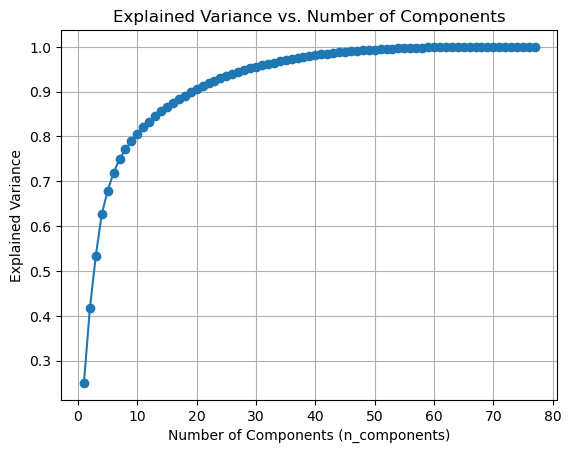

In [5]:
plt.plot(n_components_values, explained_variances, marker='o')
plt.xlabel('Number of Components (n_components)')
plt.ylabel('Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()


In [6]:
for i, ev in enumerate(explained_variances):
    if (0.8 < ev < 0.9):
        print(i, ":", "%.2f" % ev, end=", ")

9 : 0.81, 10 : 0.82, 11 : 0.83, 12 : 0.84, 13 : 0.86, 14 : 0.87, 15 : 0.87, 16 : 0.88, 17 : 0.89, 18 : 0.90, 

In [7]:
pca = PCA(n_components=12)
reduced_data = pca.fit_transform(encodings)

In [8]:
# cluster the embeddings
print("[INFO] Clustering using DBSCAN...")
clt = DBSCAN(eps=0.36, min_samples=6, metric="euclidean", n_jobs=-1)
clt.fit(reduced_data)
labelIDs = np.unique(clt.labels_)
numUniqueFaces = len(np.where(labelIDs > -1)[0])
print("[INFO] Number of unique faces: {}".format(numUniqueFaces))

[INFO] Clustering using DBSCAN...
[INFO] Number of unique faces: 6


[INFO] Faces for face ID: -1


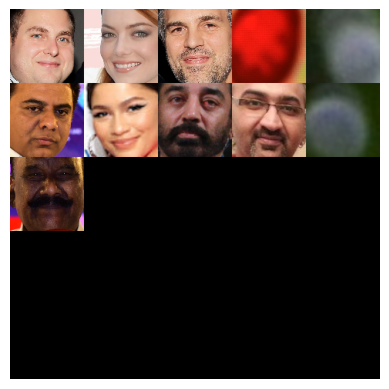

[INFO] Faces for face ID: 0


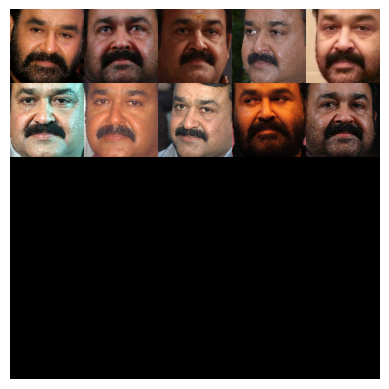

[INFO] Faces for face ID: 1


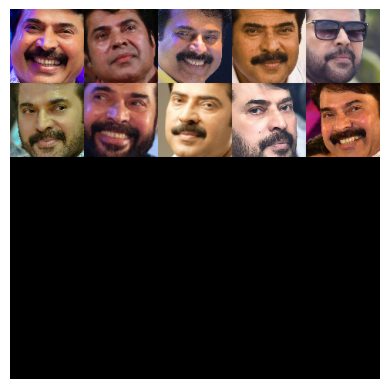

[INFO] Faces for face ID: 2


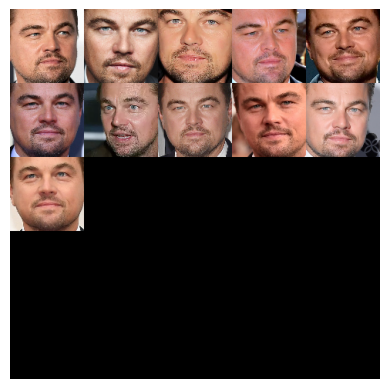

[INFO] Faces for face ID: 3


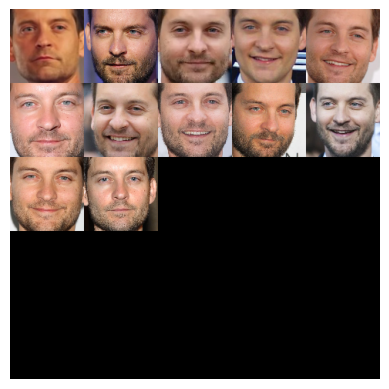

[INFO] Faces for face ID: 4


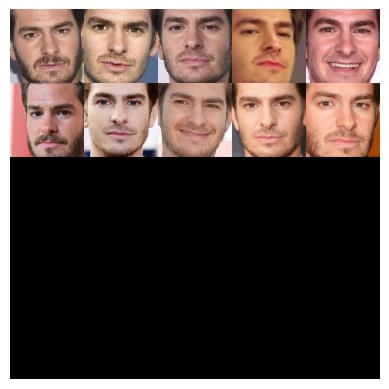

[INFO] Faces for face ID: 5


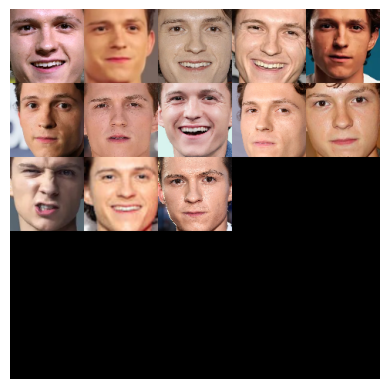

In [9]:
# loop over the unique face integers
for labelID in labelIDs:
	# find all indexes into the `data` array that belong to the
	# current label ID, then randomly sample a maximum of 25 indexes
	# from the set
	print("[INFO] Faces for face ID: {}".format(labelID))
	idxs = np.where(clt.labels_ == labelID)[0]
	idxs = np.random.choice(idxs, size=min(25, len(idxs)),
		replace=False)
	# initialize the list of faces to include in the montage
	faces = []
	
    # loop over the sampled indexes
	for i in idxs:
	    # load the input image and extract the face ROI
	    image_path = data[i]["imagePath"].replace("actorsds", "dataset")
	    image = cv2.imread(image_path)
	    (top, right, bottom, left) = data[i]["loc"]
	    face = image[top:bottom, left:right]
	    # force resize the face ROI to 96x96 and then add it to the
	    # faces montage list
	    face = cv2.resize(face, (96, 96))
	    faces.append(face)
		
        	# create a montage using 96x96 "tiles" with 5 rows and 5 columns
	montage = build_montages(faces, (96, 96), (5, 5))[0]
	rgb_image = cv2.cvtColor(montage, cv2.COLOR_BGR2RGB)
	
	# show the output montage
	title = "Face ID #{}".format(labelID)
	title = "Unknown Faces" if labelID == -1 else title
	plt.imshow(rgb_image)
	plt.axis('off')  # Optional: Turn off the axis labels
	plt.show()
		

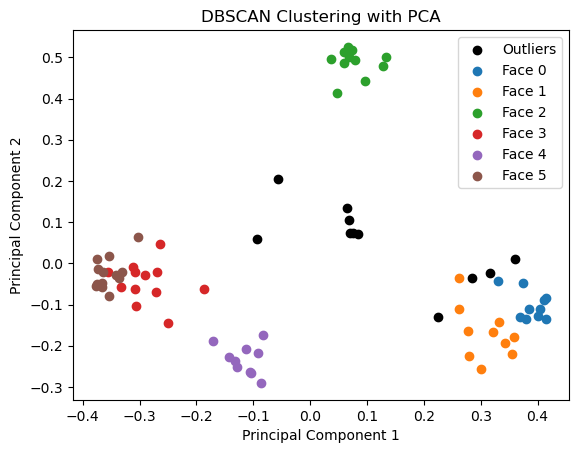

In [10]:
for label in labelIDs:
    if label == -1:
        plt.scatter(reduced_data[clt.labels_ == label, 0], reduced_data[clt.labels_ == label, 1], color='black', label='Outliers')
    else:
        plt.scatter(reduced_data[clt.labels_ == label, 0], reduced_data[clt.labels_ == label, 1], label=f'Face {label}')

plt.legend()
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clustering with PCA')
plt.show()


In [11]:
import os
import shutil
from pathlib import Path

# Create output directory
output_dir = "output"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

print("[INFO] Creating Face ID folders and organizing images...")

# loop over the unique face integers
for labelID in labelIDs:
    # Create folder for this Face ID
    face_folder = os.path.join(output_dir, f"face_{labelID}")
    os.makedirs(face_folder, exist_ok=True)
    
    # Get all indices for this label
    idxs = np.where(clt.labels_ == labelID)[0]
    print(f"[INFO] Face ID #{labelID}: Found {len(idxs)} faces")
    
    # Save individual face montage
    faces = []
    for i in idxs[:25]:  # Limit to 25 faces for montage
        image_path = data[i]["imagePath"].replace("actorsds", "dataset")
        image = cv2.imread(image_path)
        (top, right, bottom, left) = data[i]["loc"]
        face = image[top:bottom, left:right]
        face = cv2.resize(face, (96, 96))
        faces.append(face)
    
    if faces:
        montage = build_montages(faces, (96, 96), (5, 5))[0]
        montage_bgr = cv2.cvtColor(montage, cv2.COLOR_RGB2BGR) if len(montage.shape) == 3 else montage
        montage_path = os.path.join(face_folder, f"face_id_{labelID}_montage.png")
        cv2.imwrite(montage_path, montage_bgr)
        print(f"   ✓ Saved montage: {montage_path}")
    
    # Copy original images for this Face ID
    unique_images = set()
    for i in idxs:
        image_path = data[i]["imagePath"].replace("actorsds", "dataset")
        if image_path not in unique_images:
            unique_images.add(image_path)
            
            # Get original filename
            filename = os.path.basename(image_path)
            dest_path = os.path.join(face_folder, filename)
            
            # Copy the original image
            if os.path.exists(image_path):
                shutil.copy2(image_path, dest_path)
                print(f"   ✓ Copied: {filename}")

print("[INFO] Done! All Face IDs organized in 'output' folder")

[INFO] Creating Face ID folders and organizing images...
[INFO] Face ID #-1: Found 11 faces
   ✓ Saved montage: output\face_-1\face_id_-1_montage.png
   ✓ Copied: 05.JPG
   ✓ Copied: 07.jpg
   ✓ Copied: 08.JPG
   ✓ Copied: 14.jpg
   ✓ Copied: 29.jpg
   ✓ Copied: 48.jpeg
   ✓ Copied: 60.jpeg
[INFO] Face ID #0: Found 10 faces
   ✓ Saved montage: output\face_0\face_id_0_montage.png
   ✓ Copied: 01.jpg
   ✓ Copied: 02.jpg
   ✓ Copied: 03.JPG
   ✓ Copied: 04.jpg
   ✓ Copied: 05.JPG
   ✓ Copied: 06.JPG
   ✓ Copied: 07.jpg
   ✓ Copied: 08.JPG
   ✓ Copied: 09.JPG
   ✓ Copied: 10.jpg
[INFO] Face ID #1: Found 10 faces
   ✓ Saved montage: output\face_1\face_id_1_montage.png
   ✓ Copied: 05.JPG
   ✓ Copied: 11.jpg
   ✓ Copied: 12.jpg
   ✓ Copied: 13.jpg
   ✓ Copied: 14.jpg
   ✓ Copied: 15.jpg
   ✓ Copied: 16.jpg
   ✓ Copied: 17.jpg
   ✓ Copied: 18.jpg
   ✓ Copied: 19.jpg
[INFO] Face ID #2: Found 11 faces
   ✓ Saved montage: output\face_2\face_id_2_montage.png
   ✓ Copied: 20.jpg
   ✓ Copied: 21.jp